In [7]:
!pip install -q datasets scikit-learn matplotlib seaborn

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [11]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os

DATA_DIR = "/content/drive/MyDrive/ML_Project/FairFace"

print(os.listdir(DATA_DIR))

['fairface_dataset.rar']


In [13]:
!apt-get -qq install unrar

In [ ]:
!unrar x "/content/drive/MyDrive/ML_Project/FairFace/fairface_dataset.rar" \
"/content/drive/MyDrive/ML_Project/FairFace/"

In [15]:
print(os.listdir(DATA_DIR))

['fairface_dataset.rar', 'val', 'fairface-label-train.csv', 'fairface-label-val.csv', 'train']


In [16]:
import pandas as pd

train_df = pd.read_csv(
    os.path.join(DATA_DIR, "fairface-label-train.csv")
)

val_df = pd.read_csv(
    os.path.join(DATA_DIR, "fairface-label-val.csv")
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (86744, 5)
Validation: (10954, 5)


In [17]:
train_df.head()

,file,age,gender,race,service_test
0,train/1.jpg,59,Male,East Asian,True
1,train/2.jpg,39,Female,Indian,False
2,train/3.jpg,11,Female,Black,False
3,train/4.jpg,26,Female,Indian,True
4,train/5.jpg,26,Female,Indian,True


In [18]:
val_df.head()

,file,age,gender,race,service_test
0,val/1.jpg,11,Male,East Asian,False
1,val/2.jpg,51,Female,East Asian,True
2,val/3.jpg,37,Male,White,True
3,val/4.jpg,25,Female,Latino_Hispanic,True
4,val/5.jpg,24,Male,Southeast Asian,False


In [19]:
print(train_df.columns)

Index(['file', 'age', 'gender', 'race', 'service_test'], dtype='object')


In [20]:
print(train_df.iloc[0])

file            train/1.jpg
age                      59
gender                 Male
race             East Asian
service_test           True
Name: 0, dtype: object


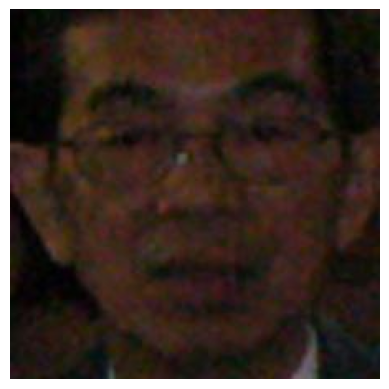

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = os.path.join(
    DATA_DIR,
    train_df.iloc[0]["file"]
)

image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

In [22]:
print("Number of training samples:", len(train_df))
print("Number of validation samples:", len(val_df))

print("\nRace distribution in training set:")
print(train_df["race"].value_counts())

print("\nRace distribution in validation set:")
print(val_df["race"].value_counts())

Number of training samples: 86744
Number of validation samples: 10954

Race distribution in training set:
race
White              16527
Latino_Hispanic    13367
Indian             12319
East Asian         12287
Black              12233
Southeast Asian    10795
Middle Eastern      9216
Name: count, dtype: int64

Race distribution in validation set:
race
White              2085
Latino_Hispanic    1623
Black              1556
East Asian         1550
Indian             1516
Southeast Asian    1415
Middle Eastern     1209
Name: count, dtype: int64


In [23]:
print("Missing values in training set:")
print(train_df.isnull().sum())

print("\nMissing values in validation set:")
print(val_df.isnull().sum())

Missing values in training set:
file            0
age             0
gender          0
race            0
service_test    0
dtype: int64

Missing values in validation set:
file            0
age             0
gender          0
race            0
service_test    0
dtype: int64


In [24]:
print(train_df["race"].unique())

['East Asian' 'Indian' 'Black' 'White' 'Middle Eastern' 'Latino_Hispanic'
 'Southeast Asian']


In [25]:
RACE_CLASSES = [
    "East Asian",
    "Indian",
    "Black",
    "White",
    "Middle Eastern",
    "Latino_Hispanic",
    "Southeast Asian"
]

print("Number of race classes:", len(RACE_CLASSES))

Number of race classes: 7


In [26]:
race_to_idx = {
    race: idx
    for idx, race in enumerate(RACE_CLASSES)
}

idx_to_race = {
    idx: race
    for race, idx in race_to_idx.items()
}

print(race_to_idx)

{'East Asian': 0, 'Indian': 1, 'Black': 2, 'White': 3, 'Middle Eastern': 4, 'Latino_Hispanic': 5, 'Southeast Asian': 6}


In [27]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [28]:
from torch.utils.data import Dataset
from PIL import Image
import os

class FairFaceDataset(Dataset):

    def __init__(self, dataframe, data_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            self.data_dir,
            row["file"]
        )

        image = Image.open(image_path).convert("RGB")

        race = race_to_idx[row["race"]]

        if self.transform:
            image = self.transform(image)

        return image, race

In [29]:
train_dataset = FairFaceDataset(
    dataframe=train_df,
    data_dir=DATA_DIR,
    transform=train_transform
)

val_dataset = FairFaceDataset(
    dataframe=val_df,
    data_dir=DATA_DIR,
    transform=val_transform
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 86744
Validation dataset size: 10954


In [30]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [31]:
images, races = next(iter(train_loader))

print("Images shape:", images.shape)
print("Races shape:", races.shape)

Images shape: torch.Size([64, 3, 224, 224])
Races shape: torch.Size([64])


In [32]:
import torch
import torch.nn as nn
from torchvision import models

class FairFaceModel(nn.Module):

    def __init__(self, num_classes=7):

        super().__init__()

        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        num_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        return self.backbone(x)

In [33]:
model = FairFaceModel(
    num_classes=len(RACE_CLASSES)
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


FairFaceModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [34]:
images, races = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 3, 224, 224])
Output shape: torch.Size([64, 7])


In [35]:
criterion = nn.CrossEntropyLoss()

In [36]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [37]:
NUM_EPOCHS = 5

best_val_accuracy = 0.0
best_model_path = "/content/drive/MyDrive/ML_Project/FairFace/best_fairface_resnet18.pth"

In [38]:
def validate(model, val_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    return epoch_loss, accuracy, f1

In [39]:
train_losses = []
val_losses = []

val_accuracies = []
val_f1_scores = []

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct / total

    val_loss, val_accuracy, val_f1 = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved!")

Epoch [1/5] | Train Loss: 1.0911 | Train Acc: 0.5847 | Val Loss: 0.9327 | Val Acc: 0.6481 | Val F1: 0.6432
Best model saved!
Epoch [2/5] | Train Loss: 0.8578 | Train Acc: 0.6771 | Val Loss: 0.8615 | Val Acc: 0.6769 | Val F1: 0.6716
Best model saved!
Epoch [3/5] | Train Loss: 0.7584 | Train Acc: 0.7176 | Val Loss: 0.8431 | Val Acc: 0.6812 | Val F1: 0.6772
Best model saved!
Epoch [4/5] | Train Loss: 0.6723 | Train Acc: 0.7506 | Val Loss: 0.8389 | Val Acc: 0.6872 | Val F1: 0.6856
Best model saved!
Epoch [5/5] | Train Loss: 0.5867 | Train Acc: 0.7844 | Val Loss: 0.8896 | Val Acc: 0.6796 | Val F1: 0.6761


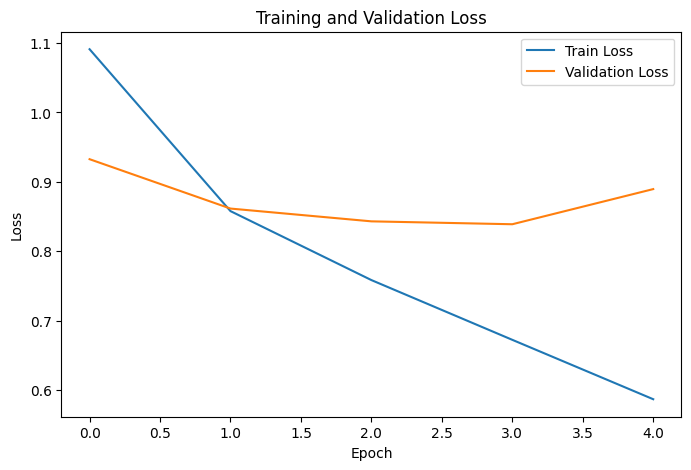

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

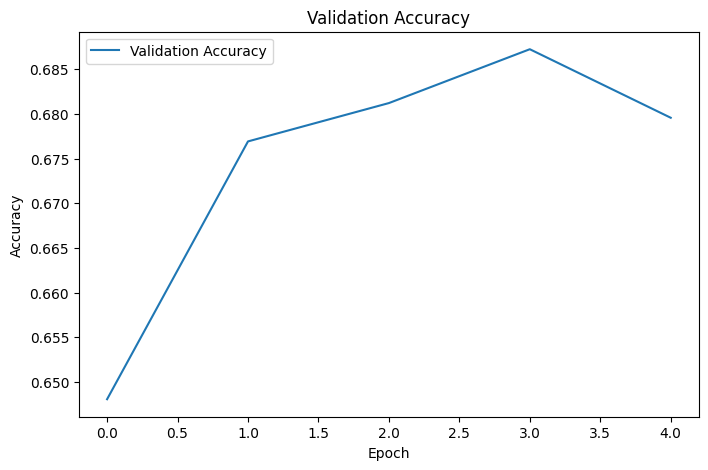

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

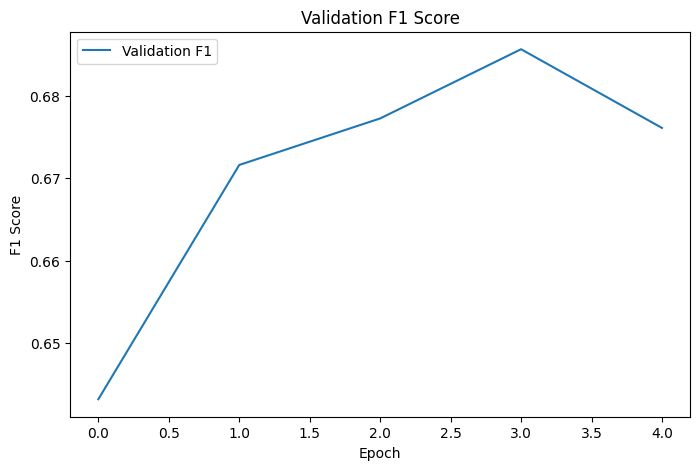

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(val_f1_scores, label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score")

plt.legend()
plt.show()

In [43]:
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.to(device)

print("Best model loaded successfully!")

Best model loaded successfully!


In [44]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [45]:
from sklearn.metrics import accuracy_score, f1_score

final_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

final_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Final Validation Accuracy: {final_accuracy:.4f}")
print(f"Final Validation F1 Score: {final_f1:.4f}")

Final Validation Accuracy: 0.6872
Final Validation F1 Score: 0.6856


In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=RACE_CLASSES
    )
)

                 precision    recall  f1-score   support

     East Asian       0.73      0.75      0.74      1550
         Indian       0.72      0.70      0.71      1516
          Black       0.85      0.85      0.85      1556
          White       0.69      0.78      0.73      2085
 Middle Eastern       0.69      0.54      0.61      1209
Latino_Hispanic       0.52      0.51      0.52      1623
Southeast Asian       0.61      0.62      0.62      1415

       accuracy                           0.69     10954
      macro avg       0.69      0.68      0.68     10954
   weighted avg       0.69      0.69      0.69     10954



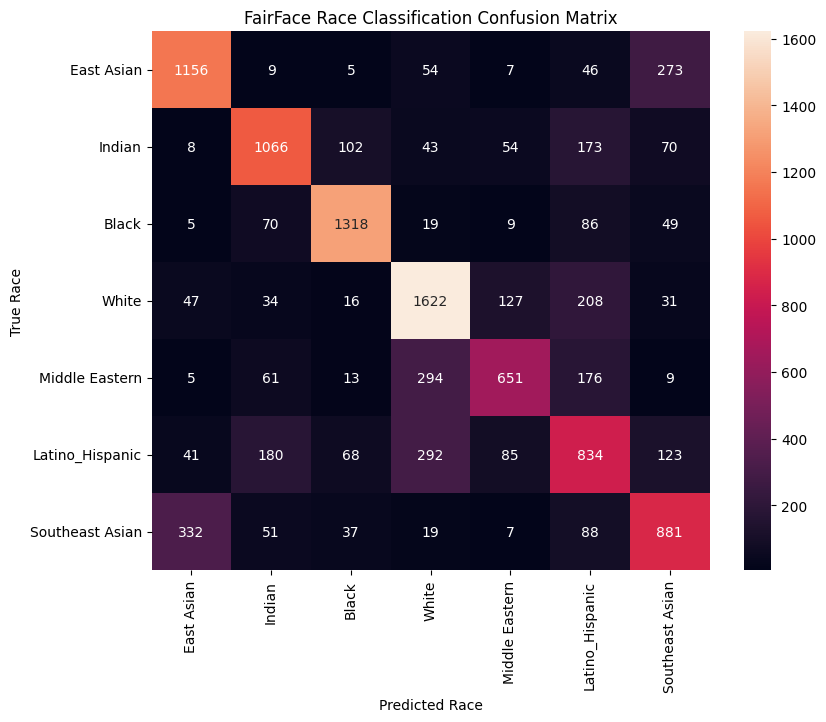

In [47]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=RACE_CLASSES,
    yticklabels=RACE_CLASSES
)

plt.xlabel("Predicted Race")
plt.ylabel("True Race")
plt.title("FairFace Race Classification Confusion Matrix")

plt.show()

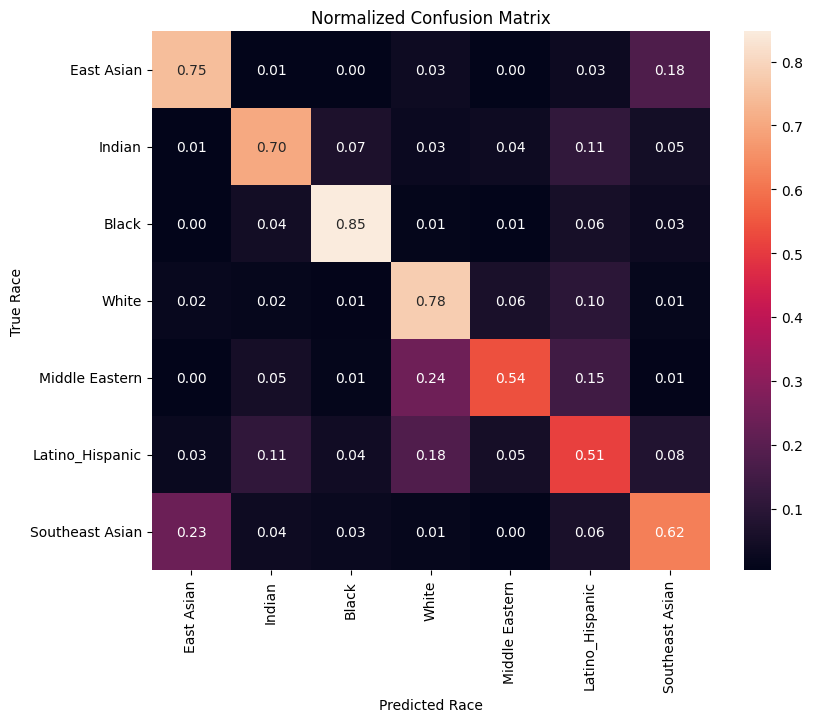

In [48]:
cm_normalized = confusion_matrix(
    all_labels,
    all_predictions,
    normalize="true"
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=RACE_CLASSES,
    yticklabels=RACE_CLASSES
)

plt.xlabel("Predicted Race")
plt.ylabel("True Race")
plt.title("Normalized Confusion Matrix")

plt.show()

In [49]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    labels=list(range(len(RACE_CLASSES))),
    zero_division=0
)

results_df = pd.DataFrame({
    "Race": RACE_CLASSES,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

results_df

,Race,Precision,Recall,F1,Support
0,East Asian,0.725220,0.745806,0.735369,1550
1,Indian,0.724677,0.703166,0.713760,1516
2,Black,0.845414,0.847044,0.846228,1556
3,White,0.692275,0.777938,0.732611,2085
4,Middle Eastern,0.692553,0.538462,0.605863,1209
5,Latino_Hispanic,0.517691,0.513863,0.515770,1623
6,Southeast Asian,0.613510,0.622615,0.618029,1415


Error Analysis

In [50]:
wrong_indices = [
    i for i, (true, pred)
    in enumerate(zip(all_labels, all_predictions))
    if true != pred
]

print("Number of wrong predictions:", len(wrong_indices))

Number of wrong predictions: 3426


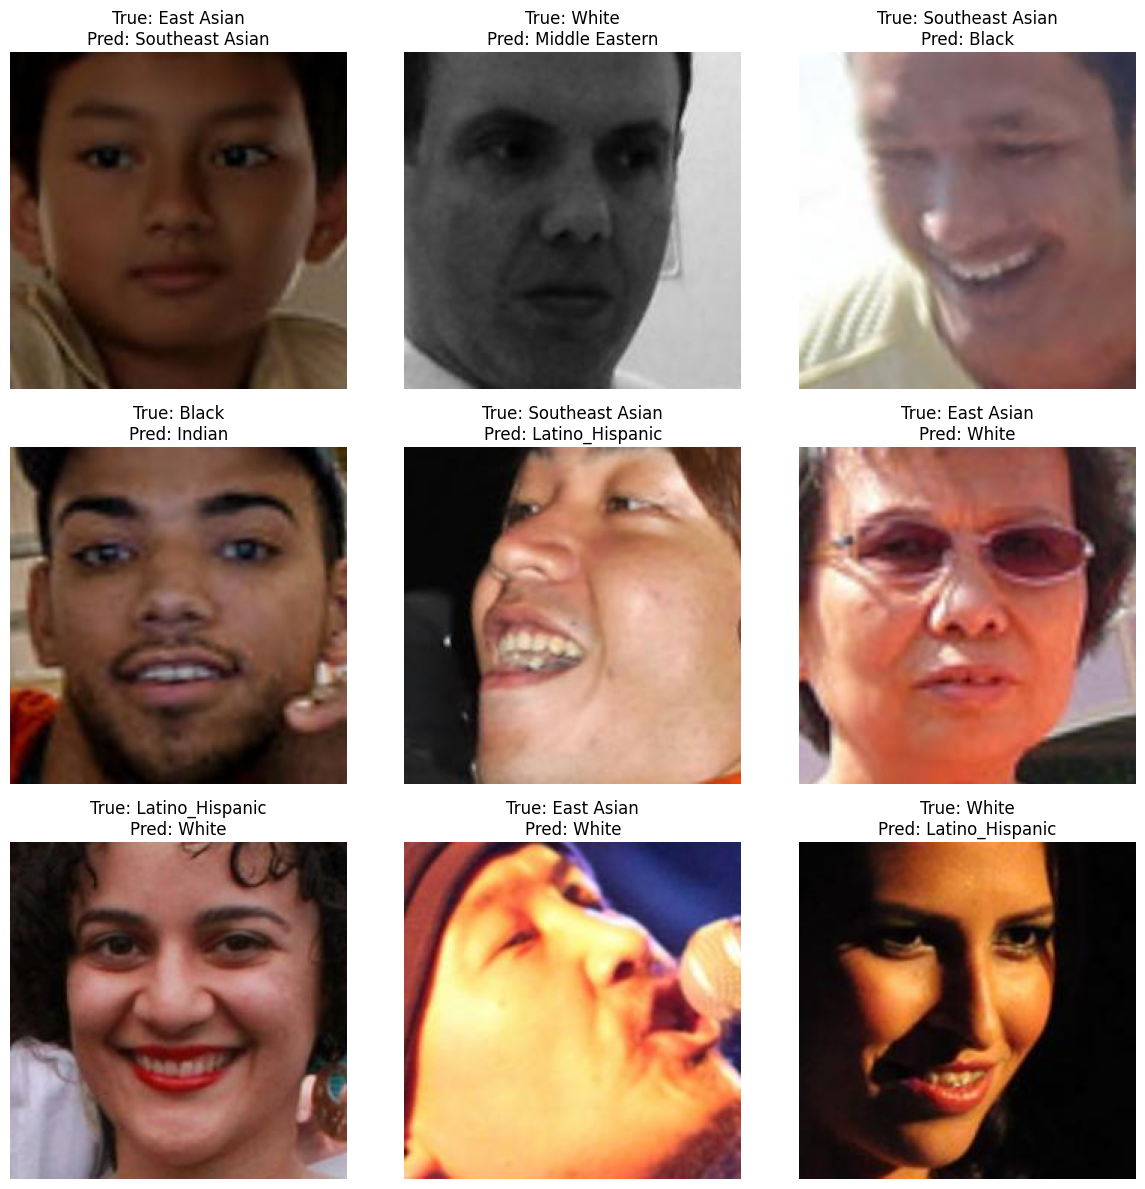

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, idx in zip(axes.flat, wrong_indices[:9]):

    image_path = os.path.join(
        DATA_DIR,
        val_df.iloc[idx]["file"]
    )

    image = Image.open(image_path)

    true_label = idx_to_race[all_labels[idx]]
    predicted_label = idx_to_race[all_predictions[idx]]

    ax.imshow(image)

    ax.set_title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()